## **The Correlation pitfalls, Illustrated with  SHAP**


**Toy structural model:** $X_1$ drives $X_2$ and $X_3$, which both feed $Y$ directly.
$X_1$ itself has **no direct edge into $Y$**.

```
X1 ---> X2 ---> Y
 \-----> X3 ---/
```

$$
X_1 \sim \mathcal{N}(0,1), \qquad X_2 = a X_1 + \varepsilon_2, \qquad X_3 = b X_1 +
\varepsilon_3, \qquad Y = c X_2 + d X_3 + \varepsilon_Y
$$

Since $Y$'s only parents are $X_2$ and $X_3$: **once $X_2$ and $X_3$ are known exactly,
$X_1$ carries no further information about $Y$** ($X_1 \perp Y \mid X_2, X_3$). This
notebook shows, with the real `shap` library, that this makes classical (marginal) Shapley
values assign $X_1$ essentially **zero** credit — even though intervening on $X_1$ changes
$Y$ substantially, through $X_2$ and $X_3$.


In [ ]:
!pip install -q shap


In [ ]:
import numpy as np
import math
from itertools import combinations
import shap
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(0)
n = 5000
a, b, c, d = 1.5, -1.0, 2.0, 1.0   # structural coefficients
sigma = 0.5                        # noise std

X1 = rng.normal(0, 1, n)
X2 = a*X1 + rng.normal(0, sigma, n)
X3 = b*X1 + rng.normal(0, sigma, n)
Y  = c*X2 + d*X3 + rng.normal(0, sigma, n)
X = np.column_stack([X1, X2, X3])

print(f"Structural coefficients: a={a}, b={b}, c={c}, d={d}")


Structural coefficients: a=1.5, b=-1.0, c=2.0, d=1.0


## **Step 1 : Fit the predictive model**

We fit a linear regression $f(x_1,x_2,x_3)\to y$ on the observed data. Because $X_1 \perp
Y \mid (X_2,X_3)$ by construction, the population-optimal coefficient on $X_1$ is exactly
zero -- the fitted model should recover this.


In [ ]:
model = LinearRegression().fit(X, Y)
print("Fitted coefficients [X1, X2, X3]:", np.round(model.coef_, 4))
print("(X1's coefficient is ~0: Y doesn't need X1 once X2, X3 are known)")


Fitted coefficients [X1, X2, X3]: [-0.02    1.9962  0.9886]
(X1's coefficient is ~0: Y doesn't need X1 once X2, X3 are known)


## **Step 2 : Classical (marginal) SHAP, using the `shap` library**

We compute genuine SHAP values (not a hand-rolled approximation) for one specific instance,
using `shap.LinearExplainer` with a background dataset for marginalization.


In [ ]:
background = shap.sample(X, 200, random_state=0)
explainer = shap.LinearExplainer(model, background)

x_instance = X[0:1]
shap_values = explainer(x_instance)

print("Instance: X1=%.4f, X2=%.4f, X3=%.4f" % tuple(x_instance[0]))
print("\nClassical (marginal) SHAP values:")
print("phi_1 (X1):", round(shap_values.values[0,0], 4))
print("phi_2 (X2):", round(shap_values.values[0,1], 4))
print("phi_3 (X3):", round(shap_values.values[0,2], 4))
print("\nCheck -- base value + sum(phi) should equal the model's prediction:")
print("base + sum(phi) =", round(shap_values.base_values[0] + shap_values.values[0].sum(), 4),
      " | model prediction =", round(model.predict(x_instance)[0], 4))


Instance: X1=0.1257, X2=0.0986, X3=0.1190

Classical (marginal) SHAP values:
phi_1 (X1): -0.0037
phi_2 (X2): 0.3693
phi_3 (X3): 0.083

Check -- base value + sum(phi) should equal the model's prediction:
base + sum(phi) = 0.3101  | model prediction = 0.3101


**What you should see:** $\phi_1 \approx 0$ (up to fitting/sampling noise), while $\phi_2$
and $\phi_3$ carry essentially all the credit. This is the *correct* answer to the question
classical SHAP actually asks ("how much does the *fitted model* $f$ rely on each input?") --
but it is easy to misread this as "$X_1$ doesn't matter," which is false about the
underlying causal system.


In [ ]:
import pandas as pd
import graphviz as gr

In [ ]:
def same(x):
    return x

def cube(x):
    return np.power(x, 3)

def negexp(x):
    return np.exp(-np.abs(x))

## **An example**

For example, Jérolon et al. considered the amount of causal effect of hormone replacement therapy (HRT) on breast cancer (BC) risk. In this applicative context, the age (A) is a covariable.

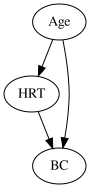

In [ ]:
g = gr.Digraph()
g.edge("HRT", "BC"), g.edge("Age","HRT"), g.edge("Age", "BC")
g

Ref : Jérolon A, Baglietto L, Birmelé E, Alarcon F, Perduca V. Causal mediation analysis in presence of multiple mediators uncausally related. The International Journal of Biostatistics. 2021 Nov 1;17(2):191-221.

##Simulation of an example

We simulate an example
$$T=f_1(a_1\cdot X+\varepsilon_1)$$
$$Y=f_2(a_2\cdot T+ b_2\cdot X+\varepsilon_2)$$
where $X,\varepsilon_1,\varepsilon_2$ are independent random variables whose distribution is known

In [ ]:
def generate_samples(size,fixed_function1,fixed_function2, dist_x,dx,a1,a2,b2,nstd,seed = None,normalize=True):
    '''Generate independent post-nonlinear samples
    Arguments:
        size : number of samples
        f1, f2 to be within {x,x^2,x^3,tanh x, e^{-|x|}, cos x}
    Output:
        Samples X,T,Y
    '''
    if seed == None:
        np.random.seed()
    else:
        np.random.seed(seed)

    if fixed_function1 == 'linear':
      f1 = same
    elif fixed_function1=='carre':
      f1 = np.square
    elif fixed_function1=='cube':
      f1 = cube
    elif fixed_function1=='negexp':
      f1 = negexp
    else:
      f1 = np.cos

    if fixed_function2 == 'linear':
      f2= same
    elif fixed_function2=='carre':
      f2 = np.square
    elif fixed_function2=='cube':
      f2 = cube
    elif fixed_function2=='negexp':
      f2 = negexp
    else:
      f2 = np.cos

    if dist_x =='gaussian':
        cov = np.eye(dx)
        mu = np.ones(dx)
        X = np.random.multivariate_normal(mu, cov, size)

    elif dist_x == 'laplace':
        X = np.random.laplace(loc=0.0, scale=1.0, size=size*dx)
        if (dx!=1):
          X = np.reshape(X,(size,dx))

    T = f1(np.dot(a1,X)+nstd * np.random.normal(0, 1, size))
    Y = f2(np.dot(a2,T)+b2*X+nstd * np.random.normal(0, 1, size))

    if normalize == True:
        X = (X - X.min()) / (X.max() - X.min())
        T = (T - T.min()) / (T.max() - T.min())
        Y = (Y - Y.min()) / (Y.max() - Y.min())

    return [X,T,Y]

In [ ]:
[X,T,Y]=generate_samples(100,'cube','carre', 'gaussian',1,1.0,2.0,1.0,1.0,43)
df_mediator=pd.DataFrame({'X':X[:,0],'T':T[:,0],'Y':Y[:,0]})
df_mediator

,X,T,Y
0,0.534263,0.260569,0.000540
1,0.263968,0.249165,0.000028
2,0.386837,0.251142,0.000085
3,0.350574,0.250173,0.000057
4,0.673522,0.281381,0.002728
...,...,...,...
95,0.423019,0.252553,0.000132
96,0.497060,0.257181,0.000337
97,0.430913,0.252929,0.000145
98,0.843581,0.329592,0.013870


##Simulation of an intervention

In [ ]:
def generate_samples_intervene(size,fixed_function1,fixed_function2, value_t,dist_x,dx,a1,a2,b2,nstd,seed = None,normalize=True):
    '''Generate independent post-nonlinear samples
    Arguments:
        size : number of samples
        f1, f2 to be within {x,x^2,x^3,tanh x, e^{-|x|}, cos x}
    Output:
        Samples T, M,Y
    '''
    print(seed)
    if seed == None:
        np.random.seed()
    else:
        np.random.seed(seed)

    if fixed_function1 == 'linear':
      f1 = same
    elif fixed_function1=='carre':
      f1 = np.square
    elif fixed_function1=='cube':
      f1 = cube
    elif fixed_function1=='negexp':
      f1 = negexp
    else:
      f1 = np.cos

    if fixed_function2 == 'linear':
      f2= same
    elif fixed_function2=='carre':
      f2 = np.square
    elif fixed_function2=='cube':
      f2 = cube
    elif fixed_function2=='negexp':
      f2 = negexp
    else:
      f2 = np.cos

    if dist_x =='gaussian':
        cov = np.eye(dx)
        mu = np.ones(dx)
        X = np.random.multivariate_normal(mu, cov, size)

    elif dist_x == 'laplace':
        X = np.random.laplace(loc=0.0, scale=1.0, size=size*dx)
        if (dx!=1):
          X = np.reshape(X,(size,dx))


    Y = f2(np.dot(a2,value_t)+b2*X+nstd * np.random.normal(0, 1, size))

    if normalize == True:
        X = (X - X.min()) / (X.max() - X.min())
        T =value_t*np.ones((len(X),1))
        Y = (Y - Y.min()) / (Y.max() - Y.min())

    return [X,T,Y]

We intervene on $T$ setting $T:=3$

In [ ]:
[X,T,Y]=generate_samples_intervene(100,'cube','carre', 3.0,'gaussian',1,1,2,1,1,43)
df_intervene=pd.DataFrame({'X':X[:,0],'T':T[:,0],'Y':Y[:,0]})
df_intervene

43


,X,T,Y
0,0.534263,3.0,0.377819
1,0.263968,3.0,0.261186
2,0.386837,3.0,0.311753
3,0.350574,3.0,0.296404
4,0.673522,3.0,0.445627
...,...,...,...
95,0.423019,3.0,0.327423
96,0.497060,3.0,0.360593
97,0.430913,3.0,0.330889
98,0.843581,3.0,0.535549


##Counterfactuals

We assume now that we have observed $(X,T,Y)=(1,-1,1)$ with $f_1=f_2:=t\mapsto t$, $a_1=a_2=b_2=1$.

We have

$T=X+\varepsilon_1$

$Y=X+T+\varepsilon_2$

What are the value of the two noises $\varepsilon_1,\varepsilon_2$?

We solve the systemand obtain : $\varepsilon_1=-2$, $\varepsilon_2=1$

What would have happen if $T:=2$?

$Y=1+2+1=4$